In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/prepared_trader_sentiment.csv')

In [8]:
sns.set_theme(style="whitegrid")


In [9]:
import pandas as pd

order_list = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print("--- Average Win Rate by Sentiment ---")
avg_win_rate = df.groupby('sentiment_label')['win_rate'].mean().reindex(order_list).reset_index()
print(avg_win_rate)

print("\n--- Average Trade Size by Sentiment ---")
avg_trade_size = df.groupby('sentiment_label')['avg_trade_size_usd'].mean().reindex(order_list).reset_index()
print(avg_trade_size)

print("\n--- Average Trade Frequency by Sentiment ---")
avg_trades = df.groupby('sentiment_label')['total_trades'].mean().reindex(order_list).reset_index()
print(avg_trades)

print("\n--- Daily PnL Stats by Sentiment ---")
# Using describe()
pnl_stats = df.groupby('sentiment_label')['daily_pnl'].describe().loc[order_list]
print(pnl_stats)

--- Average Win Rate by Sentiment ---
  sentiment_label  win_rate
0    Extreme Fear  0.329659
1            Fear  0.364033
2         Neutral  0.355414
3           Greed  0.343559
4   Extreme Greed  0.386387

--- Average Trade Size by Sentiment ---
  sentiment_label  avg_trade_size_usd
0    Extreme Fear         6773.464125
1            Fear         8975.928546
2         Neutral         6963.694861
3           Greed         6427.866594
4   Extreme Greed         5371.637182

--- Average Trade Frequency by Sentiment ---
  sentiment_label  total_trades
0    Extreme Fear    133.750000
1            Fear     98.153968
2         Neutral    100.228723
3           Greed     77.628086
4   Extreme Greed     76.030418

--- Daily PnL Stats by Sentiment ---
                 count         mean           std            min  25%  \
sentiment_label                                                         
Extreme Fear     160.0  4619.439053  29534.839183  -77308.420095  0.0   
Fear             630.0  5328.8

C:\Users\Yash Kumar\AppData\Local\Temp\ipykernel_15368\3340118056.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_label', y='daily_pnl', data=pnl_data_clipped,


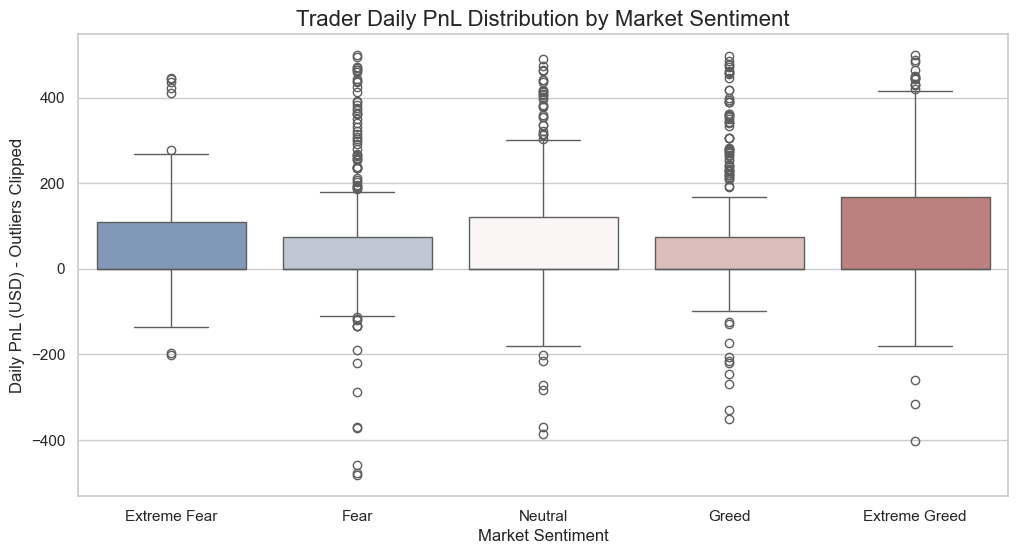

In [10]:
# --- 1: PnL Distribution by Sentiment ---
plt.figure(figsize=(12, 6))

# clipping extreme outliers for a cleaner chart
pnl_data_clipped = df[df['daily_pnl'].between(-500, 500)] 

sns.boxplot(x='sentiment_label', y='daily_pnl', data=pnl_data_clipped, 
            order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'],
            palette="vlag")

plt.title('Trader Daily PnL Distribution by Market Sentiment', fontsize=16)
plt.ylabel('Daily PnL (USD) - Outliers Clipped', fontsize=12)
plt.xlabel('Market Sentiment', fontsize=12)
plt.show()

C:\Users\Yash Kumar\AppData\Local\Temp\ipykernel_15368\2323173704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_label', y='win_rate', data=avg_win_rate, order=order_list, palette="viridis")


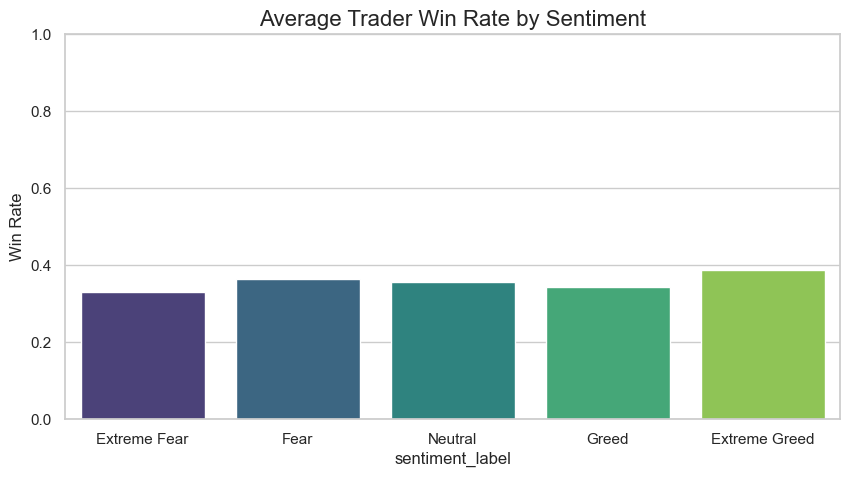

In [11]:
# ---  2: Win Rate vs. Sentiment ---
plt.figure(figsize=(10, 5))
avg_win_rate = df.groupby('sentiment_label')['win_rate'].mean().reset_index()

# Sort order
order_list = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

sns.barplot(x='sentiment_label', y='win_rate', data=avg_win_rate, order=order_list, palette="viridis")
plt.title('Average Trader Win Rate by Sentiment', fontsize=16)
plt.ylabel('Win Rate', fontsize=12)
plt.ylim(0, 1) # Win rate is between 0 and 1
plt.show()